In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from Noise_functions import *
from PC_functions import *
from DCN_functions import *
from IO_functions import *
from Noise_PC_Synapses_functions import *
from PC_DCN_Synapses_functions import *
from DCN_IO_Synapses_functions import *
from IO_PC_Synapses_functions import *
from Other_synapses import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from Input_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Frozen_data = sio.loadmat('Data/'+datetime.datetime.now().strftime("%m-%d")+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synaps = Read_Input(Frozen_data)
###################################################################
######################## Initial Parameters #######################
###################################################################
dt = Params.dt
dt_rec = Params.dt_rec
width = Params.width
tau_noise = Params.tau_noise
exp_run = Params.exp_run
N_Noise = Params.N_Noise
N_Cells_PC = Params.N_Cells_PC
N_Cells_DCN = Params.N_Cells_DCN
N_Cells_IO = Params.N_Cells_IO
N_Copy = Params.N_Copy
N_Copy_order = Params.N_Copy_order
###################################################################
########################## Cell Values ############################
###################################################################
Noise_I = Noise_frozen.Noise_I
I_recorded = Noise_frozen.I_recorded
period = Noise_frozen.period
PC_Values = Values.PC_Values
DCN_Values = Values.DCN_Values
IO_Values = Values.IO_Values
IO_thresh = Values.IO_thresh
eqs_IO_syn = Values.eqs_IO_syn
rate_meas = Values.rate_meas
rate_meas_out = Values.rate_meas_out
tau_presyn = Values.tau_presyn
tau_thresh_M = Values.tau_thresh_M
sine_amplitude_presyn = Values.sine_amplitude_presyn
sine_frequency_presyn = Values.sine_frequency_presyn
eqs_syn_bcm_s_n_pc = Values.eqs_syn_bcm_s_n_pc
###################################################################
###################### Synapses Values ############################
###################################################################
IO_Copy_Synapse_Targets = Synaps.IO_Copy_Synapse_Targets
Noise_PC_Synapse_Sources = Synaps.Noise_PC_Synapse_Sources
Noise_PC_Synapse_Targets = Synaps.Noise_PC_Synapse_Targets 
Noise_PC_Synapse_Weights = Synaps.Noise_PC_Synapse_Weights
PC_DCN_Synapse_Sources = Synaps.PC_DCN_Synapse_Sources
PC_DCN_Synapse_Targets = Synaps.PC_DCN_Synapse_Targets
DCN_IO_Synapse_Sources = Synaps.DCN_IO_Synapse_Sources 
DCN_IO_Synapse_Targets = Synaps.DCN_IO_Synapse_Targets 
IO_PC_Synapse_Sources = Synaps.IO_PC_Synapse_Sources
IO_PC_Synapse_Targets = Synaps.IO_PC_Synapse_Targets
###################################################################
###################################################################
############################## CELLS ##############################
###################################################################
###################################################################
############################## NOISE ##############################
###################################################################
Noise, Noise_statemon, Noise_extended, Noise_extended_statemon = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL ##########################
###################################################################
PC, PC_Statemon, PC_Spikemon, PC_rate = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################## DEEP CEREBELLAR NUCLEI CELLS ###################
###################################################################
DCN, DCN_Statemon, DCN_Spikemon, DCN_rate = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO ##################################
###################################################################
IO, IO_Statemon, IO_Spikemon, IO_rate = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
###################################################################
############################# PF ##################################
###################################################################
Input_presyn, Input_presyn_statemon = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate ################################
###################################################################
syn = rate_meas_func(rate_meas,PC,dt)
syn.connect(j='i')  
syn.subtract.delay = rate_meas_out  # delay the subtraction
###################################################################
############################# Copy ################################
###################################################################
conn_N_PC, mon_N_PC = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
############################## CELLS COUPLED ######################
###################################################################
###################################################################
############################## NOISE COUPLED ######################
###################################################################
Noise_Coupled, Noise_statemon_Coupled, Noise_extended_Coupled, Noise_extended_statemon_Coupled = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL COUPLED ##################
###################################################################
PC_Coupled, PC_Statemon_Coupled, PC_Spikemon_Coupled, PC_rate_Coupled = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################ DEEP CEREBELLAR NUCLEI CELLS COUPLED #############
###################################################################
DCN_Coupled, DCN_Statemon_Coupled, DCN_Spikemon_Coupled, DCN_rate_Coupled = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO COUPLED ##########################
###################################################################
IO_Coupled, IO_Statemon_Coupled, IO_Spikemon_Coupled, IO_rate_Coupled = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_synapse_Coupled = IO_coup_syn(IO_Coupled,eqs_IO_syn) # create synaptic equations and apply full synaptic strength for second network
IO_synapse_Coupled.connect() # connect second network
###################################################################
############################# PF COUPLED ##########################
###################################################################
Input_presyn_Coupled, Input_presyn_statemon_Coupled = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate COUPLED ########################
###################################################################
syn_Coupled = rate_meas_func(rate_meas,PC_Coupled,dt)
syn_Coupled.connect(j='i')  
syn_Coupled.subtract.delay = rate_meas_out  # delay the subtraction 
###################################################################
############################# Copy COUPLED ########################
###################################################################
conn_N_PC_Coupled, mon_N_PC_Coupled = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
########################## SYNAPSES ###############################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse = PC_DCN_syn(PC,DCN,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
########################## DCN IO Synapse #########################
###################################################################
DCN_IO_Synapse = DCN_IO_syn(DCN,IO,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
########################## IO ConnPC Synapse ######################
###################################################################
S_IO_N = Synapses(IO, conn_N_PC, method='euler',dt=dt)  # where f is 
S_IO_N.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
########################### IO PC Synapse #########################
###################################################################
IO_PC_Synapse = Synapses(IO, PC, on_pre ='w +=(1.5*nA)', delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
######################### ConnPC PC Synapse #######################
###################################################################
S_N_PC = Synapses(conn_N_PC,PC, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
########################## ConnPC Noise Synapse ###################
###################################################################
S_PC_N = Synapses(conn_N_PC,Noise, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
############################# Copy rate ###########################
###################################################################
copy_rate = Synapses(Input_presyn, conn_N_PC, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
############################ Copy Noise ###########################
###################################################################
copy_noise = Synapses(Noise, conn_N_PC, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise.weight = Noise_PC_Synapse_Weights
###################################################################
########################## PC Rate Synapse ########################
###################################################################
S_PC_rate = Synapses(PC,conn_N_PC, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)
###################################################################
###################################################################
####################### SYNAPSES COUPLED ##########################
###################################################################
###################################################################
#################### PC DCN Synapse COUPLED #######################
###################################################################
PC_DCN_Synapse_Coupled = PC_DCN_syn(PC_Coupled,DCN_Coupled,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse_Coupled.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
#################### DCN IO Synapse COUPLED #######################
###################################################################
DCN_IO_Synapse_Coupled = DCN_IO_syn(DCN_Coupled,IO_Coupled,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse_Coupled.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
################# IO ConnPC Synapse COUPLED #######################
###################################################################
S_IO_N_Coupled = Synapses(IO_Coupled, conn_N_PC_Coupled, method='euler',dt=dt)  # where f is 
S_IO_N_Coupled.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
##################### IO PC Synapse COUPLED #######################
###################################################################
IO_PC_Synapse_Coupled = Synapses(IO_Coupled, PC_Coupled, on_pre ='w +=(1.5*nA); try_new_bcm += 50*Hz', delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse_Coupled.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
################# ConnPC PC Synapse COUPLED #######################
###################################################################
S_N_PC_Coupled = Synapses(conn_N_PC_Coupled,PC_Coupled, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
############## ConnPC Noise Synapse COUPLED #######################
###################################################################
S_PC_N_Coupled = Synapses(conn_N_PC_Coupled,Noise_Coupled, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
######################### Copy rate COUPLED #######################
###################################################################
copy_rate_Coupled = Synapses(Input_presyn_Coupled, conn_N_PC_Coupled, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
######################## Copy Noise COUPLED #######################
###################################################################
copy_noise_Coupled = Synapses(Noise_Coupled, conn_N_PC_Coupled, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise_Coupled.weight = Noise_PC_Synapse_Weights
###################################################################
################### PC Rate Synapse COUPLED #######################
###################################################################
S_PC_rate_Coupled = Synapses(PC_Coupled,conn_N_PC_Coupled, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate_Coupled.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

ld: warning: -pie being ignored. It is only used when linking a main executable
ld: unsupported tapi file type '!tapi-tbd' in YAML file '/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/lib/libSystem.tbd' for architecture x86_64
clang-10: error: linker command failed with exit code 1 (use -v to see invocation)
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-apple-darwin13.4.0-clang++' failed with exit status 1 (LinkError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 2.44 s, sys: 436 ms, total: 2.88 s
Wall time: 5.12 s


In [2]:
###################################################################
conn_N_PC.thresh_M = 200*Hz
conn_N_PC_Coupled.thresh_M = 200*Hz
###################################################################
IO.Iapp_s = [1.0]*N_Cells_IO*uA/cm**2
IO_Coupled.Iapp_s = [1.0]*N_Cells_IO*uA/cm**2
###################################################################
########################### RUN ###################################
###################################################################
run(exp_run,report='text') # Report on the simulation

Starting simulation at t=0. s for a duration of 5. s
143.8 ms (2%) simulated in 10s, estimated 5m 38s remaining.
288.55 ms (5%) simulated in 20s, estimated 5m 27s remaining.
0.438975 s (8%) simulated in 30s, estimated 5m 12s remaining.
0.5858 s (11%) simulated in 40s, estimated 5m 1s remaining.
0.732375 s (14%) simulated in 50s, estimated 4m 51s remaining.
0.881475 s (17%) simulated in 1m 0s, estimated 4m 40s remaining.
1.029725 s (20%) simulated in 1m 10s, estimated 4m 30s remaining.
1.184325 s (23%) simulated in 1m 20s, estimated 4m 18s remaining.
1.329675 s (26%) simulated in 1m 30s, estimated 4m 8s remaining.
1.475925 s (29%) simulated in 1m 40s, estimated 3m 59s remaining.
1.623325 s (32%) simulated in 1m 50s, estimated 3m 49s remaining.
1.768075 s (35%) simulated in 2m 0s, estimated 3m 39s remaining.
1.92045 s (38%) simulated in 2m 10s, estimated 3m 28s remaining.
2.071275 s (41%) simulated in 2m 20s, estimated 3m 18s remaining.
2.2176 s (44%) simulated in 2m 30s, estimated 3m 8s

In [3]:
%%time
Create_output("_Old_New_BCM",width,Noise_statemon,Noise_extended_statemon,PC_Statemon,PC_Spikemon, PC_rate,DCN_Statemon,DCN_Spikemon, DCN_rate,IO_Statemon,IO_Spikemon,IO_rate,mon_N_PC,Noise_statemon_Coupled,Noise_extended_statemon_Coupled,PC_Statemon_Coupled,PC_Spikemon_Coupled, PC_rate_Coupled,DCN_Statemon_Coupled,DCN_Spikemon_Coupled,DCN_rate_Coupled,IO_Statemon_Coupled,IO_Spikemon_Coupled,IO_rate_Coupled,mon_N_PC_Coupled)

CPU times: user 17.4 s, sys: 172 ms, total: 17.6 s
Wall time: 2.23 s


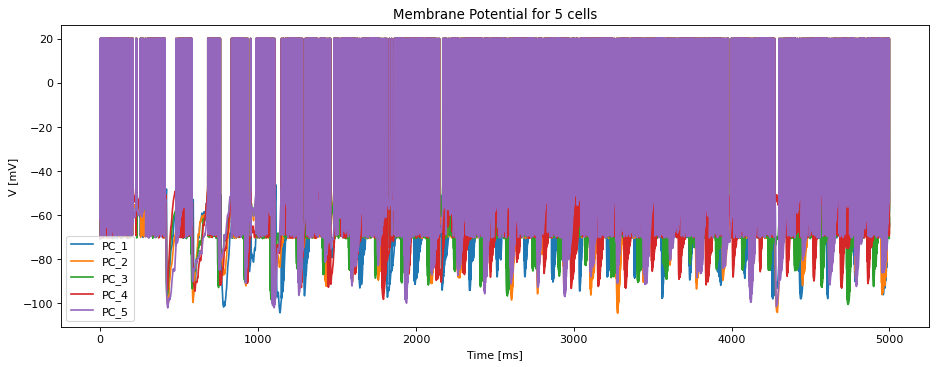

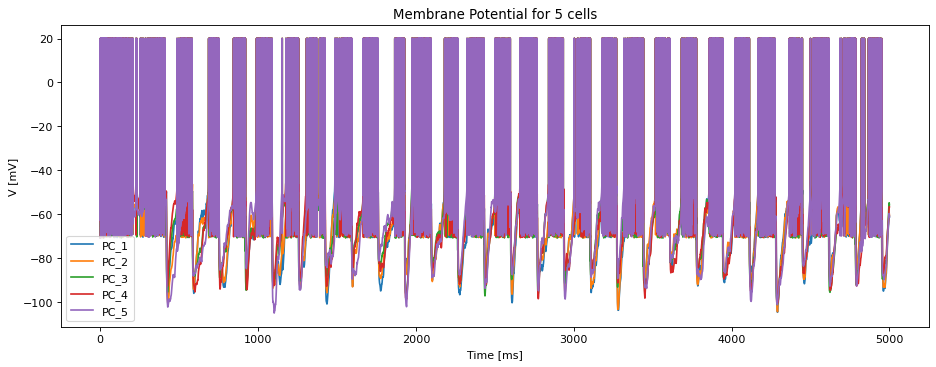

CPU times: user 2.79 s, sys: 80.2 ms, total: 2.87 s
Wall time: 2.25 s


In [4]:
%%time
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm = PC_Statemon[ii].v[:]
    for t in PC_Spikemon.t:
        i = int(t / dt_rec)
        vm[i] = 20*mV
    plot(PC_Statemon.t/ms,vm/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm_Coupled = PC_Statemon_Coupled[ii].v[:]
    for t in PC_Spikemon_Coupled.t:
        i = int(t / dt_rec)
        vm_Coupled[i] = 20*mV
    plot(PC_Statemon_Coupled.t/ms,vm_Coupled/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()